In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 


In [2]:
df=pd.read_csv("netflix.csv")

In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [5]:
df.rename(columns={"listed_in":"genre"},inplace=True)

In [6]:
df.drop("show_id",axis=1,inplace=True)

In [7]:
df.isnull().sum()

type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
genre              0
description        0
dtype: int64

In [8]:
df.dropna(subset="rating",inplace=True)

In [9]:
df.dropna(subset="date_added",inplace=True)

In [10]:
df.dropna(subset="duration",inplace=True)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8790 entries, 0 to 8806
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   type          8790 non-null   object
 1   title         8790 non-null   object
 2   director      6169 non-null   object
 3   cast          7965 non-null   object
 4   country       7961 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   genre         8790 non-null   object
 10  description   8790 non-null   object
dtypes: int64(1), object(10)
memory usage: 824.1+ KB


In [12]:
df["date_added"]=pd.to_datetime(df["date_added"],errors="coerce")

In [13]:
df.isnull().sum()

type               0
title              0
director        2621
cast             825
country          829
date_added        88
release_year       0
rating             0
duration           0
genre              0
description        0
dtype: int64

In [14]:
df.dropna(subset="date_added",inplace=True)

In [15]:
df['rating'] = df['rating'].replace(['TV-Y','TV-Y7','G','TV-G','PG','TV-PG','TV-Y7-FV'],'Kids')
df['rating'] = df['rating'].replace(['PG-13','TV-14'],'Teens')
df['rating'] = df['rating'].replace(['R','TV-MA','NC-17'],'Adults')
df['rating'] = df['rating'].replace(['NR','UR'],np.nan)
df.head()

,type,title,director,cast,country,date_added,release_year,rating,duration,genre,description
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,Teens,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,Adults,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,Adults,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,Adults,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [16]:
df.isnull().sum()

type               0
title              0
director        2538
cast             817
country          826
date_added         0
release_year       0
rating            81
duration           0
genre              0
description        0
dtype: int64

In [17]:
df.dropna(subset="rating",inplace=True)

In [18]:
df["day"]=df["date_added"].dt.day
df["month"]=df["date_added"].dt.month
df["year"]=df["date_added"].dt.year
df["month_name"]=df["date_added"].dt.month_name()
df["weekday"]=df["date_added"].dt.day_name()

In [19]:
df.head()

,type,title,director,cast,country,date_added,release_year,rating,duration,genre,description,day,month,year,month_name,weekday
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,Teens,90 min,Documentaries,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday
1,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday
2,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,Adults,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,24,9,2021,September,Friday
3,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,Adults,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",24,9,2021,September,Friday
4,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,Adults,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,24,9,2021,September,Friday


In [20]:
df["duration"]=df["duration"].apply(lambda x:int(x.split()[0]))

In [21]:
df.head()

,type,title,director,cast,country,date_added,release_year,rating,duration,genre,description,day,month,year,month_name,weekday
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,Teens,90,Documentaries,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday
1,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday
2,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,Adults,1,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,24,9,2021,September,Friday
3,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,Adults,1,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",24,9,2021,September,Friday
4,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,Adults,2,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,24,9,2021,September,Friday


In [22]:
df["type"].unique()

array(['Movie', 'TV Show'], dtype=object)

In [23]:
df_movies=df[df["type"]=="Movie"]

In [24]:
df_tvs=df[df["type"]=="TV Show"]

In [25]:
df_movies.reset_index(inplace=True,drop=True)

In [26]:
df_movies.head()

,type,title,director,cast,country,date_added,release_year,rating,duration,genre,description,day,month,year,month_name,weekday
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,Teens,90,Documentaries,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday
1,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,2021-09-24,2021,Kids,91,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,24,9,2021,September,Friday
2,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,Adults,125,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",24,9,2021,September,Friday
3,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,Teens,104,"Comedies, Dramas",A woman adjusting to life after a loss contend...,24,9,2021,September,Friday
4,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic",2021-09-23,2021,Adults,127,"Dramas, International Movies",After most of her family is murdered in a terr...,23,9,2021,September,Thursday


<Axes: xlabel='weekday'>

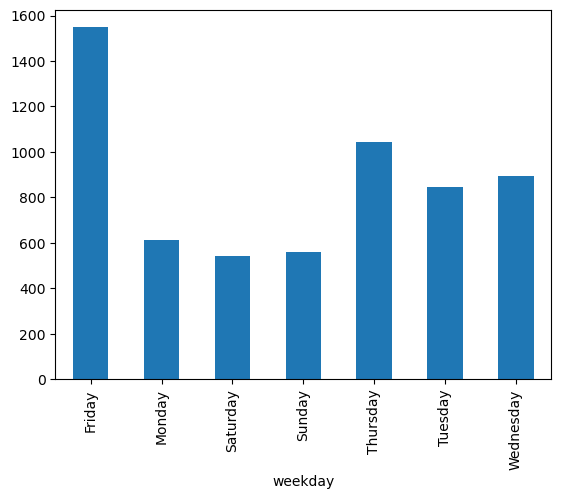

In [27]:
df_movies.groupby("weekday")["weekday"].value_counts().plot(kind="bar")

<Axes: xlabel='month_name'>

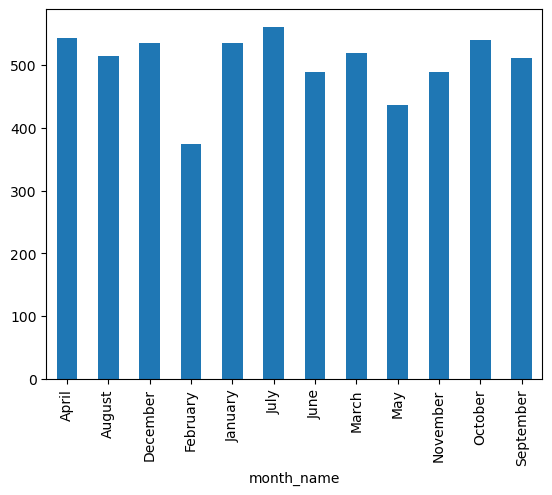

In [28]:
df_movies.groupby("month_name")["month_name"].value_counts().plot(kind="bar")

<Axes: xlabel='year'>

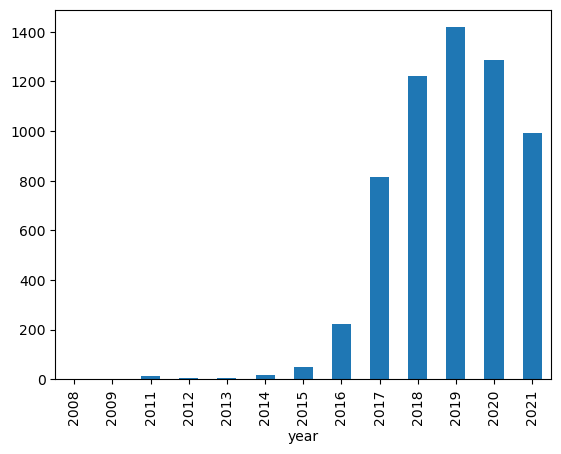

In [29]:
df_movies.groupby("year")["year"].value_counts().plot(kind="bar")

<Axes: xlabel='weekday'>

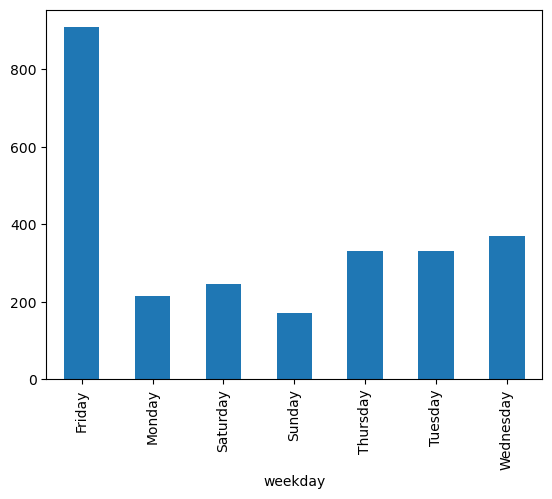

In [30]:
df_tvs.groupby("weekday")["weekday"].value_counts().plot(kind="bar")

<Axes: xlabel='month_name'>

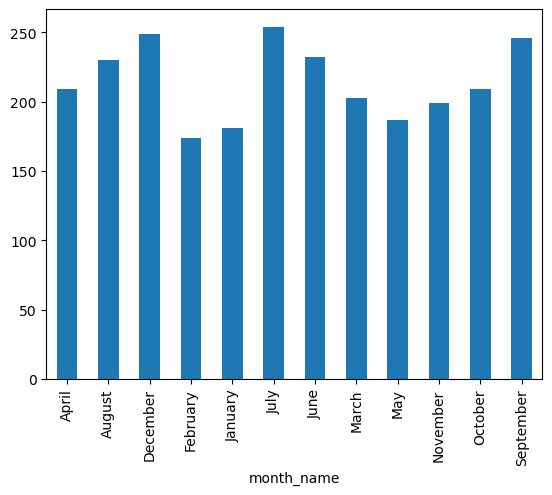

In [31]:
df_tvs.groupby("month_name")["month_name"].value_counts().plot(kind="bar")

<Axes: xlabel='year'>

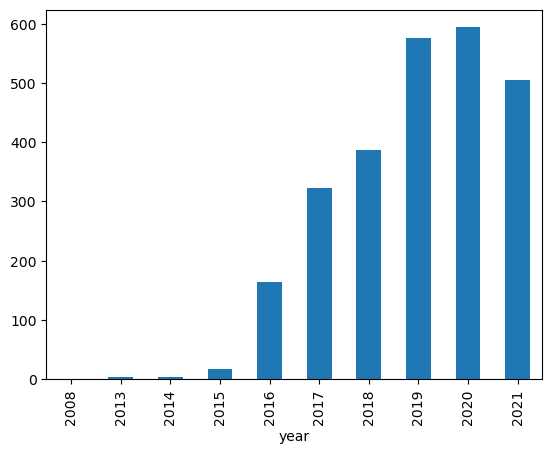

In [32]:
df_tvs.groupby("year")["year"].value_counts().plot(kind="bar")

<Axes: xlabel='count', ylabel='weekday'>

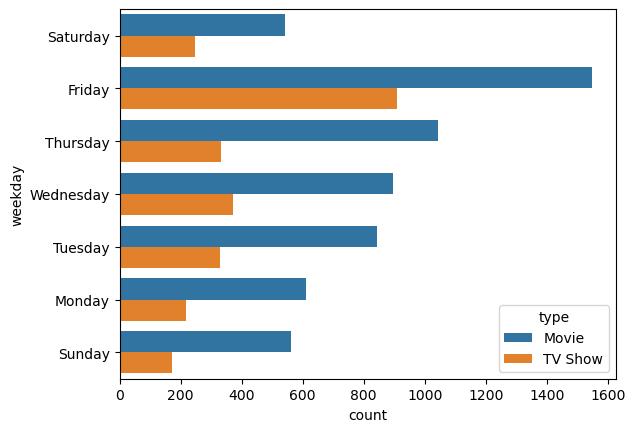

In [33]:
sns.countplot(y="weekday",data=df,hue="type")

<Axes: xlabel='count', ylabel='month_name'>

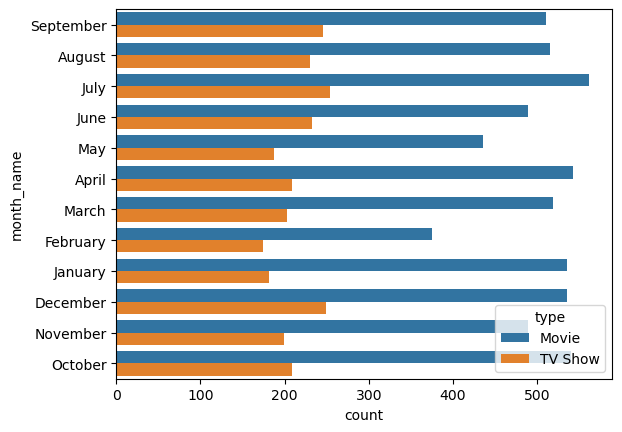

In [34]:
sns.countplot(y="month_name",data=df,hue="type")

<Axes: xlabel='count', ylabel='year'>

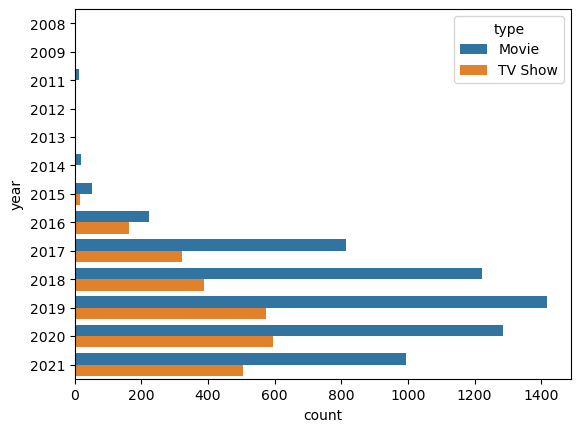

In [35]:
sns.countplot(y="year",data=df,hue="type")

In [36]:
# Now  we will have about 48% missing data .so,we will check in which rows the director,country and caast all three are null,if all these 3 are null then there is no use of that row 

In [37]:
df[(df["director"].isna())&(df["country"].isna())&(df["cast"].isna())].shape[0]

96

In [38]:
df.dropna(subset= ["director","country","cast"],how="all",inplace=True)
df.shape


(8525, 16)

In [39]:
df.isna().sum()

type               0
title              0
director        2439
cast             704
country          730
date_added         0
release_year       0
rating             0
duration           0
genre              0
description        0
day                0
month              0
year               0
month_name         0
weekday            0
dtype: int64

In [40]:
df["cast"][2].split(", ")

['Sami Bouajila',
 'Tracy Gotoas',
 'Samuel Jouy',
 'Nabiha Akkari',
 'Sofia Lesaffre',
 'Salim Kechiouche',
 'Noureddine Farihi',
 'Geert Van Rampelberg',
 'Bakary Diombera']

In [41]:
df_cast=pd.DataFrame(df["cast"].apply(lambda x: str(x).split(", ")).tolist(),index=df["title"])
df_cast

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
title,,,,,,,,,,,,,,,,,,,,,
Dick Johnson Is Dead,nan,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
Blood & Water,Ama Qamata,Khosi Ngema,Gail Mabalane,Thabang Molaba,Dillon Windvogel,Natasha Thahane,Arno Greeff,Xolile Tshabalala,Getmore Sithole,Cindy Mahlangu,...,None,None,None,None,None,None,None,None,None,None
Ganglands,Sami Bouajila,Tracy Gotoas,Samuel Jouy,Nabiha Akkari,Sofia Lesaffre,Salim Kechiouche,Noureddine Farihi,Geert Van Rampelberg,Bakary Diombera,None,...,None,None,None,None,None,None,None,None,None,None
Kota Factory,Mayur More,Jitendra Kumar,Ranjan Raj,Alam Khan,Ahsaas Channa,Revathi Pillai,Urvi Singh,Arun Kumar,None,None,...,None,None,None,None,None,None,None,None,None,None
Midnight Mass,Kate Siegel,Zach Gilford,Hamish Linklater,Henry Thomas,Kristin Lehman,Samantha Sloyan,Igby Rigney,Rahul Kohli,Annarah Cymone,Annabeth Gish,...,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Zinzana,Ali Suliman,Saleh Bakri,Yasa,Ali Al-Jabri,Mansoor Alfeeli,Ahd,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
Zodiac,Mark Ruffalo,Jake Gyllenhaal,Robert Downey Jr.,Anthony Edwards,Brian Cox,Elias Koteas,Donal Logue,John Carroll Lynch,Dermot Mulroney,Chloë Sevigny,...,None,None,None,None,None,None,None,None,None,None
Zombieland,Jesse Eisenberg,Woody Harrelson,Emma Stone,Abigail Breslin,Amber Heard,Bill Murray,Derek Graf,None,None,None,...,None,None,None,None,None,None,None,None,None,None


In [42]:
df_cast=df_cast.stack()
df_cast

title                  
Dick Johnson Is Dead  0                      nan
Blood & Water         0               Ama Qamata
                      1              Khosi Ngema
                      2            Gail Mabalane
                      3           Thabang Molaba
                                   ...          
Zubaan                3         Manish Chaudhary
                      4             Meghna Malik
                      5            Malkeet Rauni
                      6           Anita Shabdish
                      7    Chittaranjan Tripathy
Length: 63644, dtype: object

In [43]:
df_cast=pd.DataFrame(df_cast)
df_cast

0
title                                        
Dick Johnson Is Dead 0                    nan
Blood & Water        0             Ama Qamata
                     1            Khosi Ngema
                     2          Gail Mabalane
                     3         Thabang Molaba
...                                       ...
Zubaan               3       Manish Chaudhary
                     4           Meghna Malik
                     5          Malkeet Rauni
                     6         Anita Shabdish
                     7  Chittaranjan Tripathy

[63644 rows x 1 columns]

In [44]:
df_cast.reset_index(inplace=True)
df_cast

,title,level_1,0
0,Dick Johnson Is Dead,0,nan
1,Blood & Water,0,Ama Qamata
2,Blood & Water,1,Khosi Ngema
3,Blood & Water,2,Gail Mabalane
4,Blood & Water,3,Thabang Molaba
...,...,...,...
63639,Zubaan,3,Manish Chaudhary
63640,Zubaan,4,Meghna Malik
63641,Zubaan,5,Malkeet Rauni
63642,Zubaan,6,Anita Shabdish


In [45]:
df_cast =  df_cast[["title",0]]
df_cast

,title,0
0,Dick Johnson Is Dead,nan
1,Blood & Water,Ama Qamata
2,Blood & Water,Khosi Ngema
3,Blood & Water,Gail Mabalane
4,Blood & Water,Thabang Molaba
...,...,...
63639,Zubaan,Manish Chaudhary
63640,Zubaan,Meghna Malik
63641,Zubaan,Malkeet Rauni
63642,Zubaan,Anita Shabdish


In [46]:
df_cast.columns=["title","cast"]
df_cast

,title,cast
0,Dick Johnson Is Dead,nan
1,Blood & Water,Ama Qamata
2,Blood & Water,Khosi Ngema
3,Blood & Water,Gail Mabalane
4,Blood & Water,Thabang Molaba
...,...,...
63639,Zubaan,Manish Chaudhary
63640,Zubaan,Meghna Malik
63641,Zubaan,Malkeet Rauni
63642,Zubaan,Anita Shabdish


In [47]:
df_cast.replace("nan",np.nan,inplace=True)
df_cast.isna().sum()

C:\Users\nitti\AppData\Local\Temp\ipykernel_15536\356088169.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cast.replace("nan",np.nan,inplace=True)


title      0
cast     704
dtype: int64

In [48]:
df_genre=pd.DataFrame(df["genre"].apply(lambda x: str(x).split(", ")).tolist(),index=df["title"])
df_genre=df_genre.stack()
df_genre=pd.DataFrame(df_genre)
df_genre.reset_index(inplace=True)
df_genre=df_genre[["title",0]]
df_genre.columns=("title","genre")
df_genre.replace("nan",np.nan,inplace=True)
df_genre.isna().sum()

title    0
genre    0
dtype: int64

In [49]:
df_director=pd.DataFrame(df["director"].apply(lambda x: str(x).split(", ")).tolist(),index=df["title"])
df_director=df_director.stack()
df_director=pd.DataFrame(df_director)
df_director.reset_index(inplace=True)
df_director=df_director[["title",0]]
df_director.columns=("title","director")
df_director.replace("nan",np.nan,inplace=True)
df_director.isna().sum()

title          0
director    2439
dtype: int64

In [50]:
df_country=pd.DataFrame(df["country"].apply(lambda x: str(x).split(", ")).tolist(),index=df["title"])
df_country=df_country.stack()
df_country=pd.DataFrame(df_country)
df_country.reset_index(inplace=True)
df_country=df_country[["title",0]]
df_country.columns=("title","country")
df_country.replace("nan",np.nan,inplace=True)
df_country.isna().sum()

title        0
country    730
dtype: int64

In [51]:
df12=df_cast.merge(df_genre,on="title")
df12

,title,cast,genre
0,Dick Johnson Is Dead,NaN,Documentaries
1,Blood & Water,Ama Qamata,International TV Shows
2,Blood & Water,Ama Qamata,TV Dramas
3,Blood & Water,Ama Qamata,TV Mysteries
4,Blood & Water,Khosi Ngema,International TV Shows
...,...,...,...
146662,Zubaan,Anita Shabdish,International Movies
146663,Zubaan,Anita Shabdish,Music & Musicals
146664,Zubaan,Chittaranjan Tripathy,Dramas
146665,Zubaan,Chittaranjan Tripathy,International Movies


In [52]:
df123=df_director.merge(df12,on="title")
df123

,title,director,cast,genre
0,Dick Johnson Is Dead,Kirsten Johnson,NaN,Documentaries
1,Blood & Water,NaN,Ama Qamata,International TV Shows
2,Blood & Water,NaN,Ama Qamata,TV Dramas
3,Blood & Water,NaN,Ama Qamata,TV Mysteries
4,Blood & Water,NaN,Khosi Ngema,International TV Shows
...,...,...,...,...
158309,Zubaan,Mozez Singh,Anita Shabdish,International Movies
158310,Zubaan,Mozez Singh,Anita Shabdish,Music & Musicals
158311,Zubaan,Mozez Singh,Chittaranjan Tripathy,Dramas
158312,Zubaan,Mozez Singh,Chittaranjan Tripathy,International Movies


In [53]:
df1234=df_country.merge(df123,on="title")
df1234

,title,country,director,cast,genre
0,Dick Johnson Is Dead,United States,Kirsten Johnson,NaN,Documentaries
1,Blood & Water,South Africa,NaN,Ama Qamata,International TV Shows
2,Blood & Water,South Africa,NaN,Ama Qamata,TV Dramas
3,Blood & Water,South Africa,NaN,Ama Qamata,TV Mysteries
4,Blood & Water,South Africa,NaN,Khosi Ngema,International TV Shows
...,...,...,...,...,...
198399,Zubaan,India,Mozez Singh,Anita Shabdish,International Movies
198400,Zubaan,India,Mozez Singh,Anita Shabdish,Music & Musicals
198401,Zubaan,India,Mozez Singh,Chittaranjan Tripathy,Dramas
198402,Zubaan,India,Mozez Singh,Chittaranjan Tripathy,International Movies


In [54]:
df_new=df.merge(df1234,on="title")

In [55]:
df_new

,type,title,director_x,cast_x,country_x,date_added,release_year,rating,duration,genre_x,description,day,month,year,month_name,weekday,country_y,director_y,cast_y,genre_y
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,Teens,90,Documentaries,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday,United States,Kirsten Johnson,NaN,Documentaries
1,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,NaN,Ama Qamata,International TV Shows
2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,NaN,Ama Qamata,TV Dramas
3,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,NaN,Ama Qamata,TV Mysteries
4,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,NaN,Khosi Ngema,International TV Shows
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198399,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,Teens,111,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2,3,2019,March,Saturday,India,Mozez Singh,Anita Shabdish,International Movies
198400,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,Teens,111,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2,3,2019,March,Saturday,India,Mozez Singh,Anita Shabdish,Music & Musicals
198401,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,Teens,111,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2,3,2019,March,Saturday,India,Mozez Singh,Chittaranjan Tripathy,Dramas
198402,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,Teens,111,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2,3,2019,March,Saturday,India,Mozez Singh,Chittaranjan Tripathy,International Movies


In [56]:
df_new.drop(columns=["cast_x","country_x","director_x","genre_x" ],inplace=True)
df_new.rename(columns={"country_y":"country","director_y":"director","cast_y":"cast","genre_y":"genre"},inplace=True)
df_new.head()

,type,title,date_added,release_year,rating,duration,description,day,month,year,month_name,weekday,country,director,cast,genre
0,Movie,Dick Johnson Is Dead,2021-09-25,2020,Teens,90,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday,United States,Kirsten Johnson,NaN,Documentaries
1,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,NaN,Ama Qamata,International TV Shows
2,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,NaN,Ama Qamata,TV Dramas
3,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,NaN,Ama Qamata,TV Mysteries
4,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,NaN,Khosi Ngema,International TV Shows


In [57]:
df_new["cast"]=df_new["cast"].replace(np.nan,"Unkown")
df_new["country"]=df_new["country"].replace(np.nan,"Unkown")
df_new["director"]=df_new["director"].replace(np.nan,"Unkown")

In [58]:
df_new.head()

,type,title,date_added,release_year,rating,duration,description,day,month,year,month_name,weekday,country,director,cast,genre
0,Movie,Dick Johnson Is Dead,2021-09-25,2020,Teens,90,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday,United States,Kirsten Johnson,Unkown,Documentaries
1,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,Unkown,Ama Qamata,International TV Shows
2,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,Unkown,Ama Qamata,TV Dramas
3,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,Unkown,Ama Qamata,TV Mysteries
4,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,Unkown,Khosi Ngema,International TV Shows


In [59]:
df_new.duplicated().sum()

np.int64(55)

In [60]:
df_new.drop_duplicates(keep="first",inplace=True)

In [61]:
df_new.shape

(198349, 16)

In [62]:
df_movies=df_new[df_new["type"]=="Movie"]
df_tvs=df_new[df_new["type"]=="TV Show"]

In [63]:
df_movies.shape

(144240, 16)

In [64]:
df_tvs.shape

(54109, 16)

In [65]:
df_tvs.rename(columns={"duration":"seasons"},inplace=True)

C:\Users\nitti\AppData\Local\Temp\ipykernel_15536\2462203523.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tvs.rename(columns={"duration":"seasons"},inplace=True)


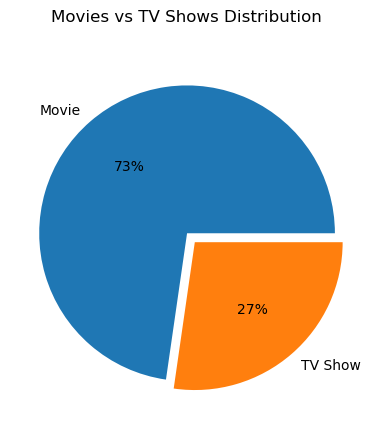

In [66]:
# labels= ["Movie","TV Show"]
plt.pie(df_new["type"].value_counts(),labels=df_new["type"].value_counts().index,explode=(0.08,0),autopct="%0.0f%%")
plt.suptitle("Movies vs TV Shows Distribution")
plt.show()

In [67]:
df_temp=df_new.drop_duplicates(subset=["country","title"])
x=df_temp["country"].value_counts().head(10)

In [68]:
x

country
United States     3596
India             1038
United Kingdom     772
Unkown             730
Canada             427
France             383
Japan              313
Spain              228
Germany            223
South Korea        222
Name: count, dtype: int64

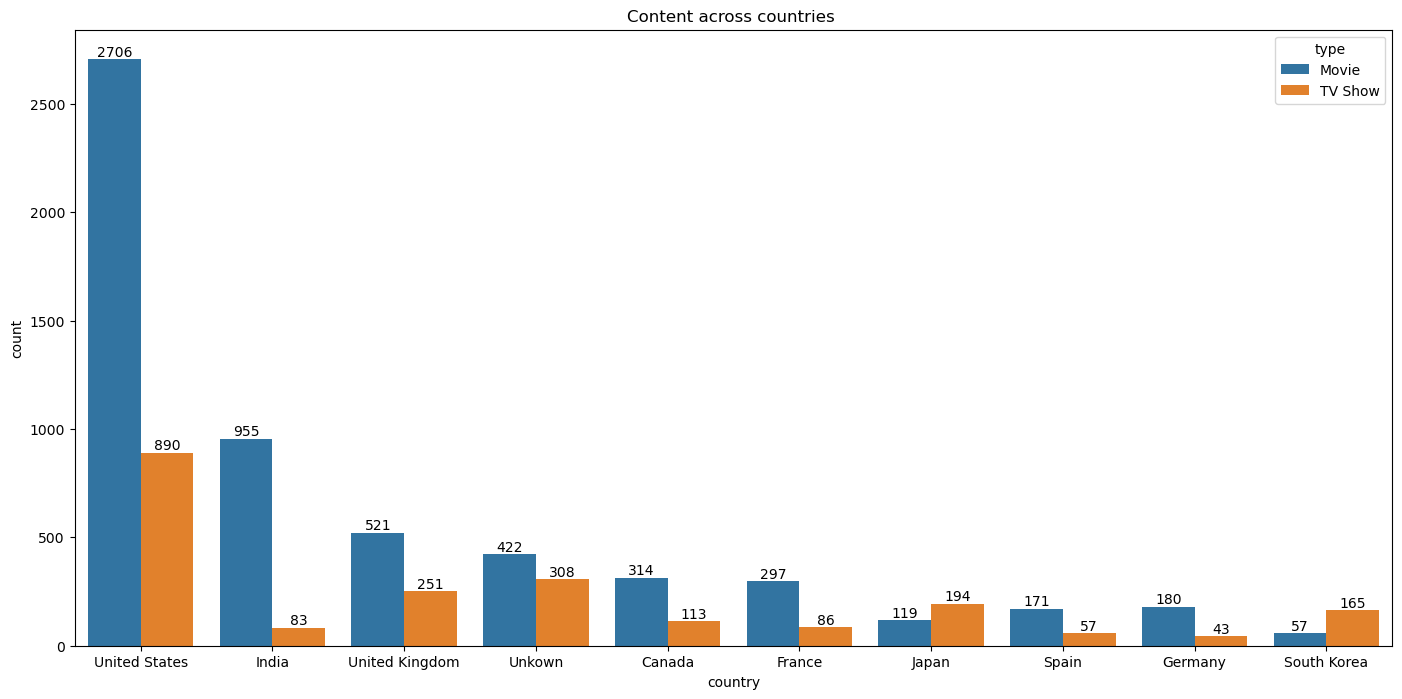

In [69]:
plt.figure(figsize=(17,8))
plt.title("Content across countries ")
label=sns.countplot(data=df_temp,x="country",hue="type",order=x.index)
for i in label.containers:
    label.bar_label(i)
plt.show()

C:\Users\nitti\AppData\Local\Temp\ipykernel_15536\2197647540.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label=sns.countplot(data=df_movies_temp,x="director",order=df_movies_temp["director"].value_counts()[1:11].index,palette="husl")
C:\Users\nitti\AppData\Local\Temp\ipykernel_15536\2197647540.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label=sns.countplot(data=df_tvs_temp,x="director",order=df_tvs_temp["director"].value_counts()[1:11].index,palette="husl")


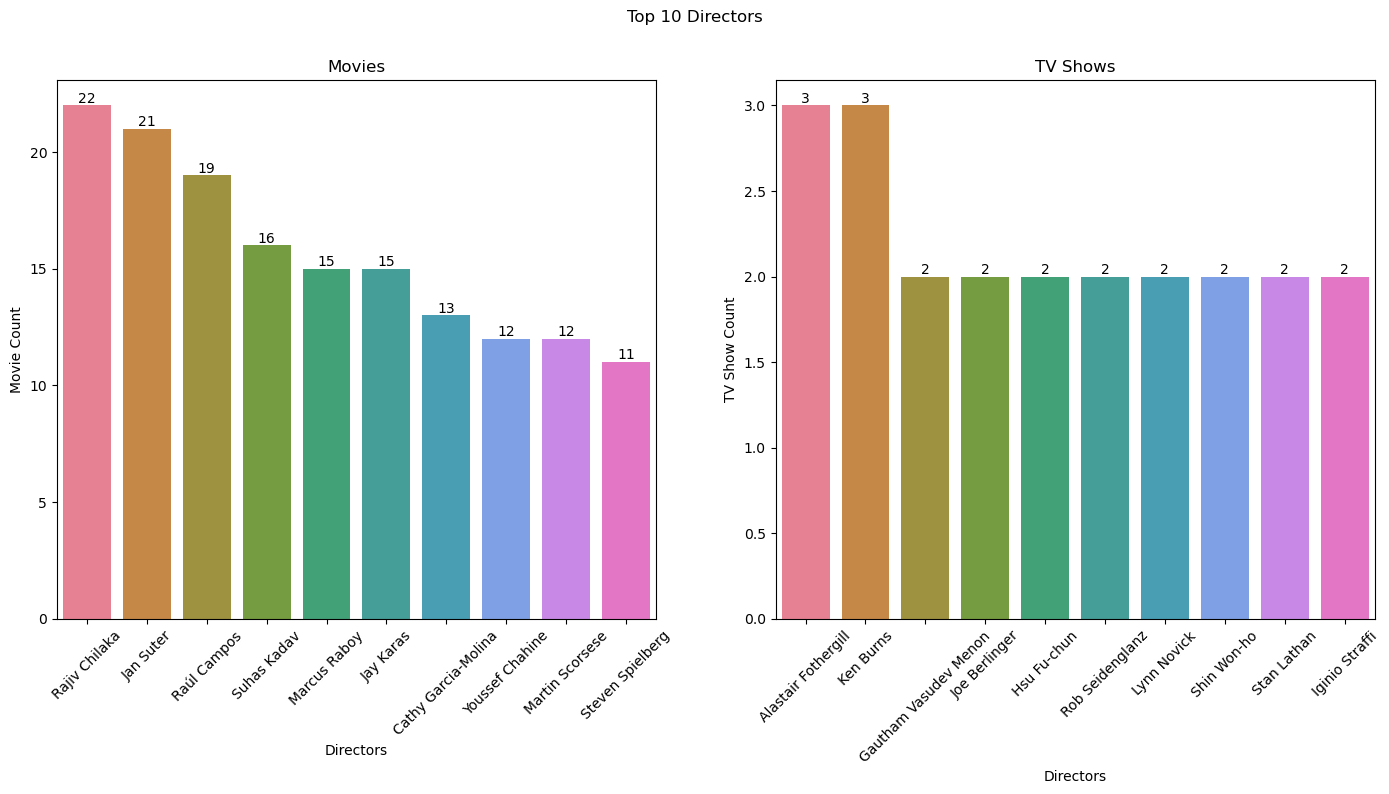

In [70]:
df_movies_temp=df_movies.drop_duplicates(subset=["director","title"])
df_tvs_temp=df_tvs.drop_duplicates(subset=["director","title"])

plt.figure(figsize=(17,7))
plt.suptitle("Top 10 Directors")
plt.subplot(1,2,1)
label=sns.countplot(data=df_movies_temp,x="director",order=df_movies_temp["director"].value_counts()[1:11].index,palette="husl")
for i in label.containers:
    label.bar_label(i)
plt.title("Movies")
plt.xticks(rotation=45)
plt.xlabel("Directors")
plt.ylabel("Movie Count")

plt.subplot(1,2,2)
label=sns.countplot(data=df_tvs_temp,x="director",order=df_tvs_temp["director"].value_counts()[1:11].index,palette="husl")
for i in label.containers:
    label.bar_label(i)
plt.title("TV Shows")
plt.xticks(rotation=45)
plt.xlabel("Directors")
plt.ylabel("TV Show Count")

plt.show()

C:\Users\nitti\AppData\Local\Temp\ipykernel_15536\3508734229.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label=sns.countplot(data=df_movies_temp,x="genre",order=df_movies_temp["genre"].value_counts()[1:11].index,palette="husl")
C:\Users\nitti\AppData\Local\Temp\ipykernel_15536\3508734229.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label=sns.countplot(data=df_tvs_temp,x="genre",order=df_tvs_temp["genre"].value_counts()[1:11].index,palette="husl")


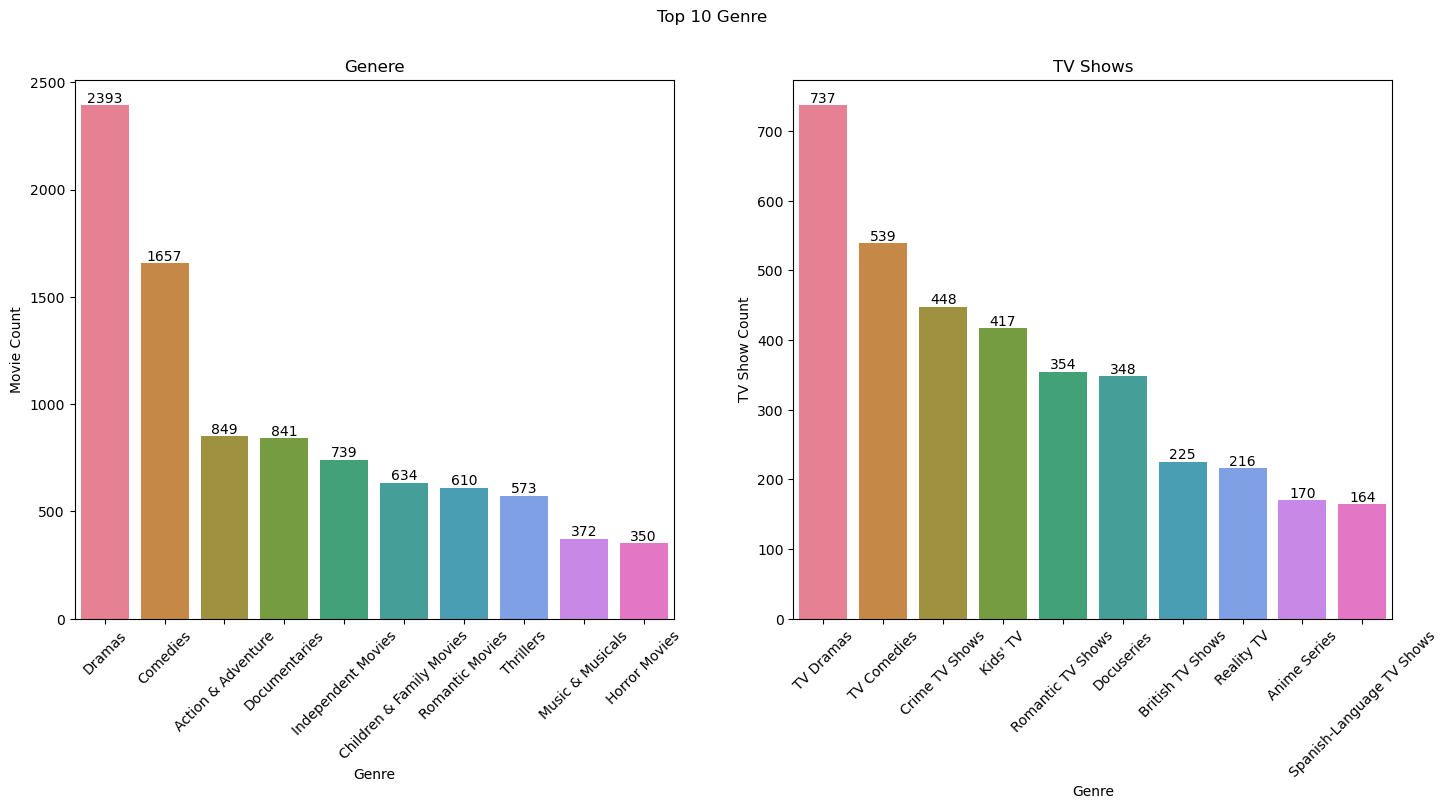

In [71]:
df_movies_temp=df_movies.drop_duplicates(subset=["genre","title"])
df_tvs_temp=df_tvs.drop_duplicates(subset=["genre","title"])

plt.figure(figsize=(17,7))
plt.suptitle("Top 10 Genre")
plt.subplot(1,2,1)
label=sns.countplot(data=df_movies_temp,x="genre",order=df_movies_temp["genre"].value_counts()[1:11].index,palette="husl")
for i in label.containers:
    label.bar_label(i)
plt.title("Genere")
plt.xticks(rotation=45)
plt.xlabel("Genre")
plt.ylabel("Movie Count")

plt.subplot(1,2,2)
label=sns.countplot(data=df_tvs_temp,x="genre",order=df_tvs_temp["genre"].value_counts()[1:11].index,palette="husl")
for i in label.containers:
    label.bar_label(i)
plt.title("TV Shows")
plt.xticks(rotation=45)
plt.xlabel("Genre")
plt.ylabel("TV Show Count")

plt.show()

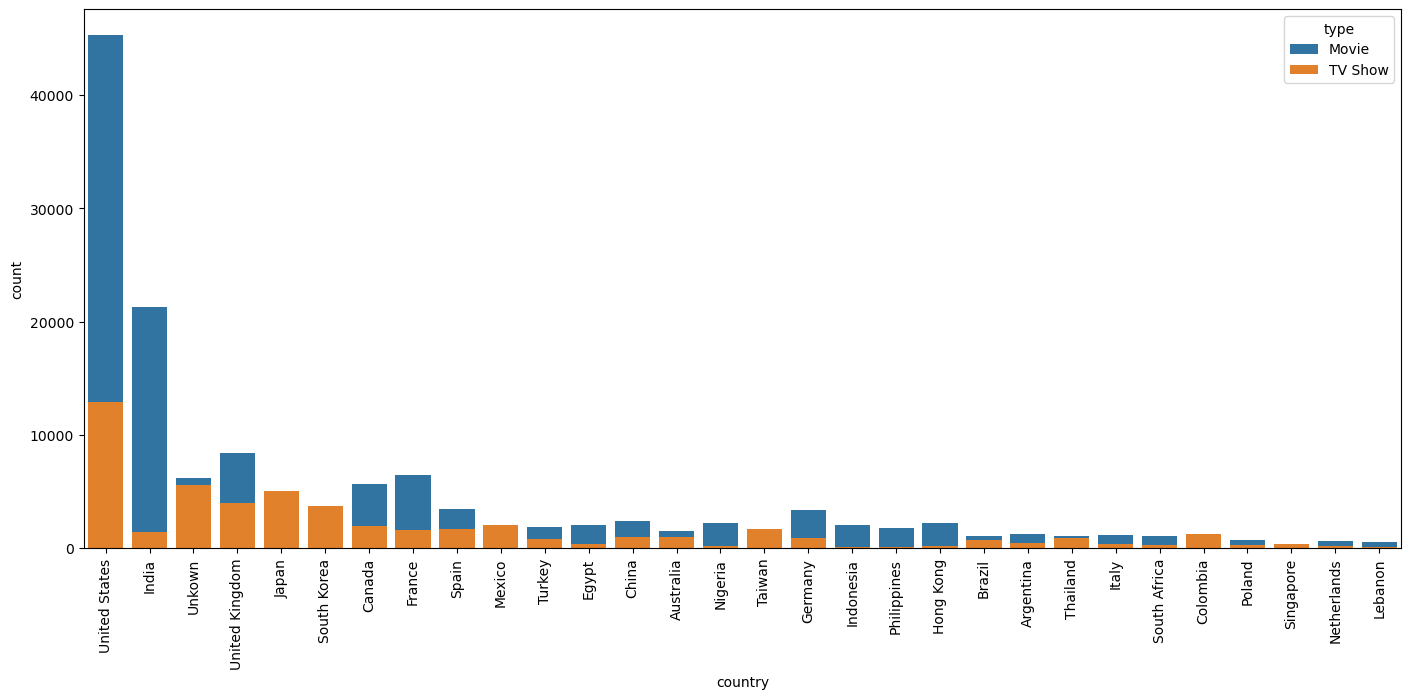

In [72]:
df_temp=df_new.drop_duplicates(subset=["genre","title"])

plt.figure(figsize=(17,7))
plt.xticks(rotation=90)
sns.countplot(data=df_new,x="country",hue="type",dodge=False,order=df_temp["country"].value_counts().head(30).index)
plt.show()

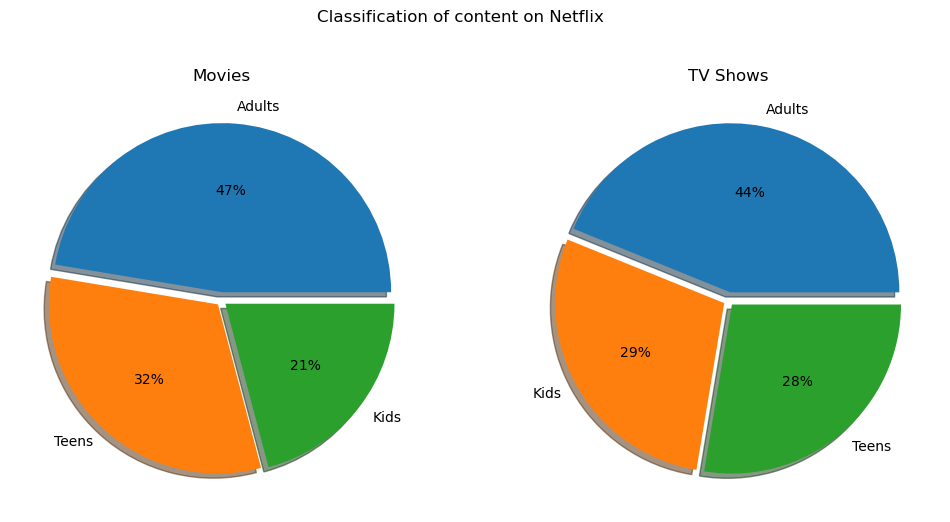

In [73]:
df_movies_temp=df_movies.drop_duplicates(subset=["rating","title"])
df_tvs_temp=df_tvs.drop_duplicates(subset=["rating","title"])

plt.figure(figsize=(12,6))
plt.suptitle("Classification of content on Netflix")

plt.subplot(1,2,1)
plt.pie(df_movies_temp["rating"].value_counts(),labels=df_movies_temp["rating"].value_counts().index,autopct="%.0f%%",explode=(0.05,0.03,0.03),shadow=True)
plt.title("Movies")

plt.subplot(1,2,2)
plt.pie(df_tvs_temp["rating"].value_counts(),labels=df_tvs_temp["rating"].value_counts().index,autopct="%.0f%%",explode=(0.05,0.03,0.03),shadow=True)
plt.title("TV Shows")

plt.show()


C:\Users\nitti\AppData\Local\Temp\ipykernel_15536\970115909.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label=sns.countplot(data=df_movies_temp,x="year",order=mv_year.index,palette="husl")
C:\Users\nitti\AppData\Local\Temp\ipykernel_15536\970115909.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label=sns.countplot(data=df_movies_temp,x="month_name",order=mv_month.index,palette="husl")
C:\Users\nitti\AppData\Local\Temp\ipykernel_15536\970115909.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label=sns.countplot(data=df_movies_temp,x="weekday",order=mv_day.in

Text(0.5, 1.0, 'Day Wise')

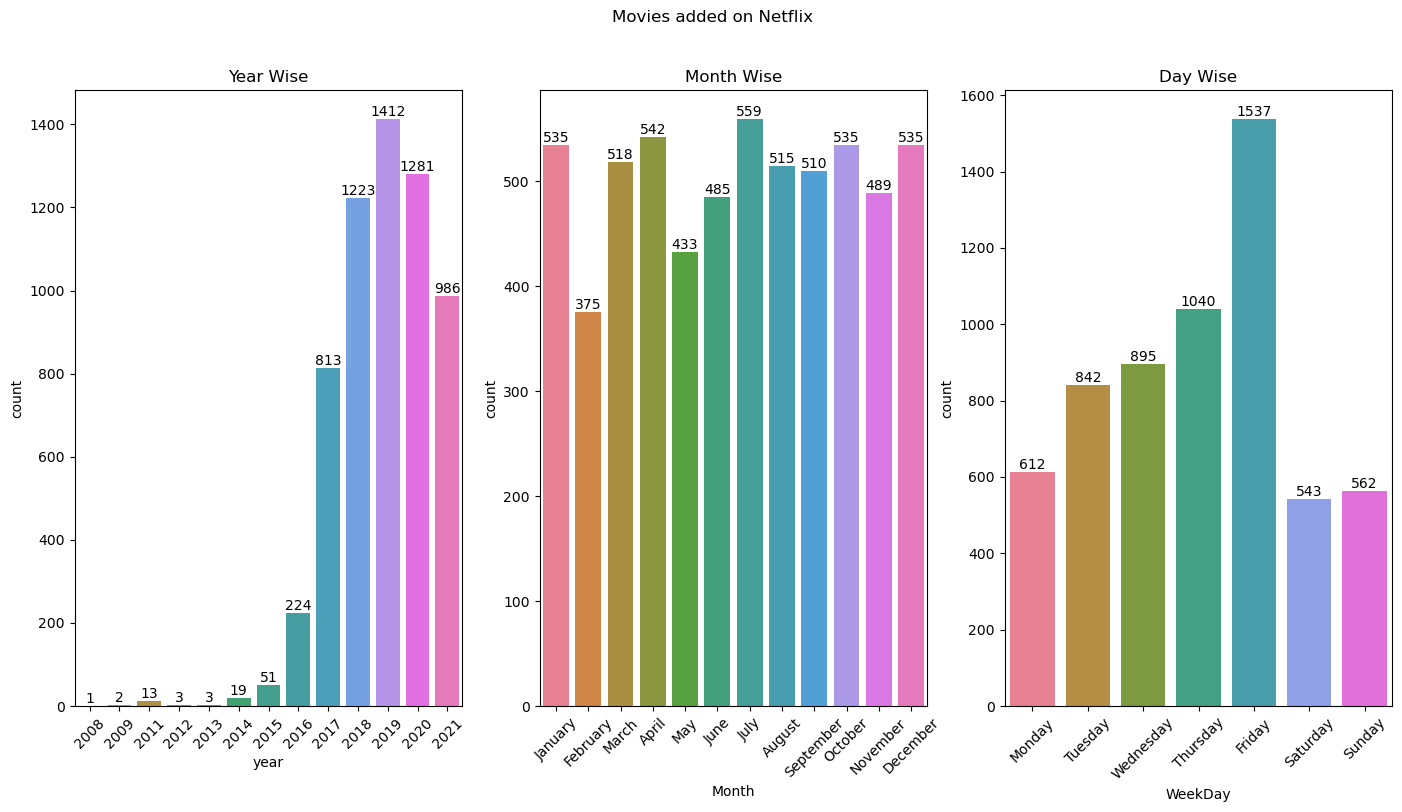

In [75]:
df_movies_temp=df_movies.drop_duplicates(subset=["year","title"])


mv_year=df_movies_temp["year"].value_counts()
mv_year.sort_index(inplace=True)

month_order=["January","February","March","April","May","June","July","August","September","October","November","December"]
mv_month=df_movies_temp["month_name"].value_counts().loc[month_order]

day_order=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
mv_day=df_movies_temp["weekday"].value_counts().loc[day_order]

plt.figure(figsize=(17,8))
plt.suptitle("Movies added on Netflix")

plt.subplot(1,3,1)
label=sns.countplot(data=df_movies_temp,x="year",order=mv_year.index,palette="husl")
for i in label.containers:
    label.bar_label(i)
plt.xticks(rotation=45)
plt.xlabel("year")
plt.title("Year Wise")


plt.subplot(1,3,2)
label=sns.countplot(data=df_movies_temp,x="month_name",order=mv_month.index,palette="husl")
for i in label.containers:
    label.bar_label(i)
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.title("Month Wise")

plt.subplot(1,3,3)
label=sns.countplot(data=df_movies_temp,x="weekday",order=mv_day.index,palette="husl")
for i in label.containers:
    label.bar_label(i)
plt.xticks(rotation=45)
plt.xlabel("WeekDay")
plt.title("Day Wise")


C:\Users\nitti\AppData\Local\Temp\ipykernel_15536\3664121534.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label=sns.countplot(data=df_tvs_temp,x="year",order=mv_year.index,palette="husl")
C:\Users\nitti\AppData\Local\Temp\ipykernel_15536\3664121534.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label=sns.countplot(data=df_tvs_temp,x="month_name",order=mv_month.index,palette="husl")
C:\Users\nitti\AppData\Local\Temp\ipykernel_15536\3664121534.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label=sns.countplot(data=df_tvs_temp,x="weekday",order=mv_day.index,pa

Text(0.5, 1.0, 'Day Wise')

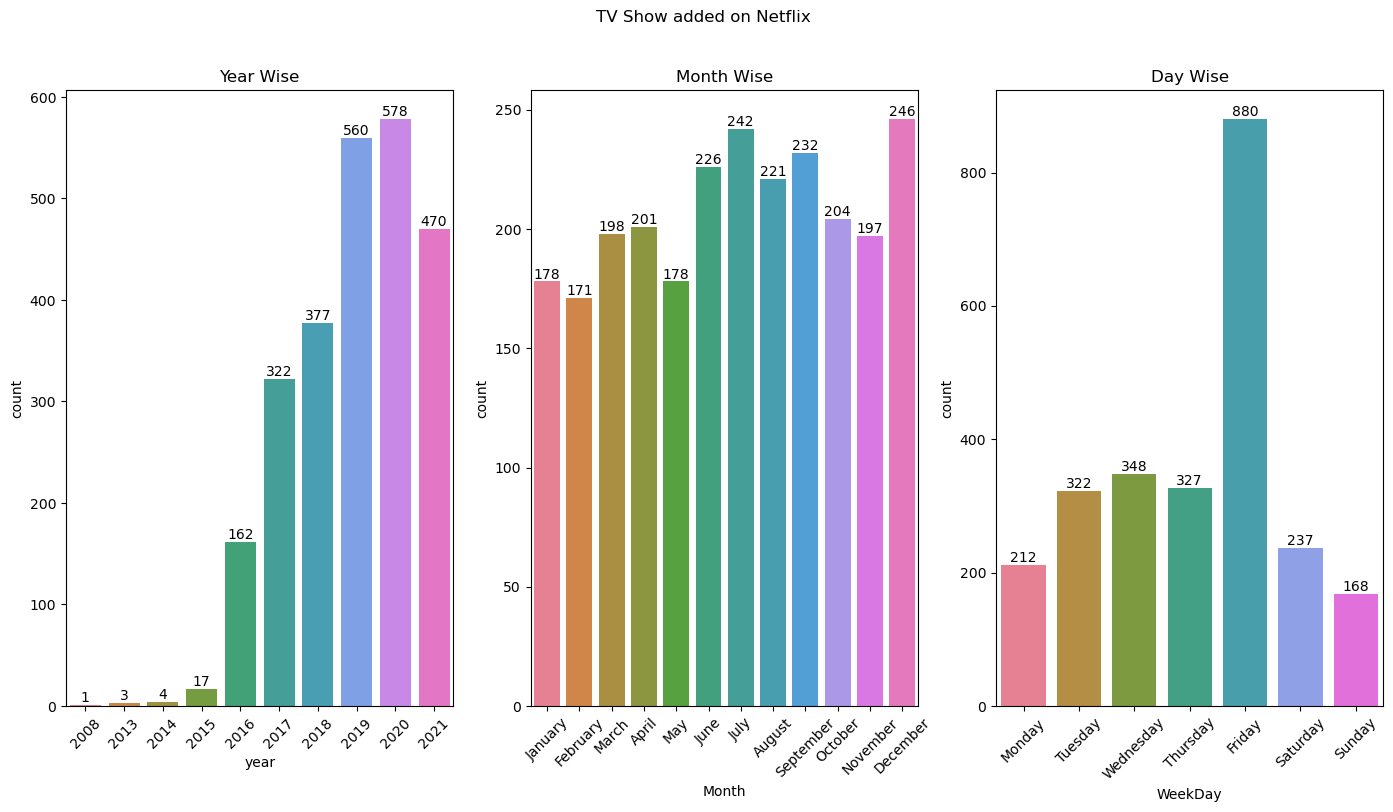

In [76]:
df_tvs_temp=df_tvs.drop_duplicates(subset=["year","title"])


mv_year=df_tvs_temp["year"].value_counts()
mv_year.sort_index(inplace=True)

month_order=["January","February","March","April","May","June","July","August","September","October","November","December"]
mv_month=df_tvs_temp["month_name"].value_counts().loc[month_order]

day_order=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
mv_day=df_tvs_temp["weekday"].value_counts().loc[day_order]

plt.figure(figsize=(17,8))
plt.suptitle("TV Show added on Netflix")

plt.subplot(1,3,1)
label=sns.countplot(data=df_tvs_temp,x="year",order=mv_year.index,palette="husl")
for i in label.containers:
    label.bar_label(i)
plt.xticks(rotation=45)
plt.xlabel("year")
plt.title("Year Wise")


plt.subplot(1,3,2)
label=sns.countplot(data=df_tvs_temp,x="month_name",order=mv_month.index,palette="husl")
for i in label.containers:
    label.bar_label(i)
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.title("Month Wise")

plt.subplot(1,3,3)
label=sns.countplot(data=df_tvs_temp,x="weekday",order=mv_day.index,palette="husl")
for i in label.containers:
    label.bar_label(i)
plt.xticks(rotation=45)
plt.xlabel("WeekDay")
plt.title("Day Wise")

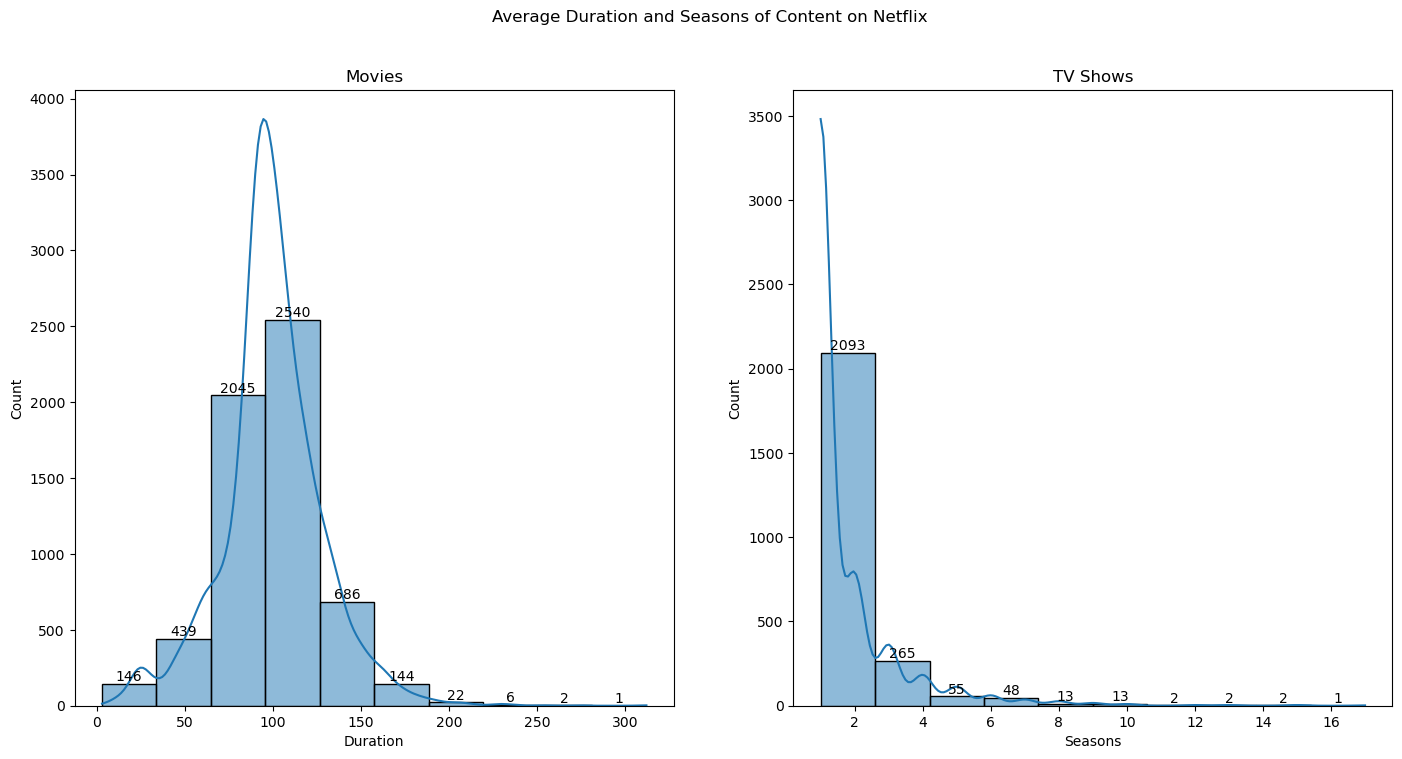

In [77]:
df_movies_temp=df_movies.drop_duplicates(subset=["duration","title"])
df_tvs_temp=df_tvs.drop_duplicates(subset=["seasons","title"])

plt.figure(figsize=(17,8))
plt.suptitle("Average Duration and Seasons of Content on Netflix ")

plt.subplot(1,2,1)
label=sns.histplot(df_movies_temp["duration"].astype(int),bins=10,kde=True)
for i in label.containers:
    label.bar_label(i)
plt.xlabel("Duration")
plt.title("Movies")

plt.subplot(1,2,2)
label=sns.histplot(df_tvs_temp["seasons"].astype(int),bins=10,kde=True)
for i in label.containers:
    label.bar_label(i)
plt.xlabel("Seasons")
plt.title("TV Shows")

plt.show()
